In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.metrics import pairwise_distances
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [3]:
# ------------------ Cargar y limpiar datos ------------------

gdf_nodos = gpd.read_file("dataset_final.gpkg")

# Asegurar CRS métrico (EPSG:3857)
if gdf_nodos.crs is None:
    gdf_nodos = gdf_nodos.set_crs(epsg=4326)
if gdf_nodos.crs.to_epsg() != 3857:
    gdf_nodos = gdf_nodos.to_crs(epsg=3857)

# Filtrar geometrías válidas
gdf_nodos = gdf_nodos[
    gdf_nodos.geometry.notnull() &
    (~gdf_nodos.geometry.is_empty) &
    (gdf_nodos.is_valid)
]

# Convertir a puntos si hay polígonos o líneas
geom_types = gdf_nodos.geometry.geom_type.unique()
if not np.all(np.isin(geom_types, ["Point", "MultiPoint"])):
    gdf_nodos = gdf_nodos.copy()
    gdf_nodos["geometry"] = gdf_nodos.geometry.centroid

# Asegurar columna osmid
if "osmid" not in gdf_nodos.columns:
    gdf_nodos["osmid"] = np.arange(len(gdf_nodos))

gdf = gdf_nodos

In [4]:
# ------------------ Funciones de fitness ------------------

def fitness_cantidad_estaciones(estaciones_osmid, factor=1.0):
    return np.float64(len(estaciones_osmid) * factor)


def fitness_prioridad_simple(gdf, estaciones_osmid, peso_flujo=0.7, peso_esquinas=0.3):
    flujo_norm = gdf['flujo_total'] / (gdf['flujo_total'].max() + 1e-6)
    esquinas_norm = gdf['esquinas_en_radio'] / (gdf['esquinas_en_radio'].max() + 1e-6)
    gdf['prioridad'] = peso_flujo * flujo_norm + peso_esquinas * esquinas_norm
    prioridades = gdf.loc[gdf['osmid'].isin(estaciones_osmid), 'prioridad']
    return np.float64(prioridades.mean() if len(prioridades) > 0 else 0.0)


def fitness_cobertura_global(gdf_nodos, estaciones_idx, d_max=50000, penalizacion=1e6):
    if gdf_nodos.empty or 'geometry' not in gdf_nodos:
        raise ValueError("❌ gdf_nodos debe ser un GeoDataFrame con geometría válida.")
    if len(estaciones_idx) == 0:
        raise ValueError("❌ Debe haber al menos una estación.")

    # Extraer coordenadas
    coords = np.vstack((gdf_nodos.geometry.x, gdf_nodos.geometry.y)).T
    estaciones = coords[np.array(estaciones_idx)]

    # Calcular distancias nodo-estación
    dist_matrix = pairwise_distances(coords, estaciones, metric='euclidean')
    dist_min = dist_matrix.min(axis=1)

    # Penalizar los que superan d_max
    penalizadas = dist_min.copy()
    penalizadas[penalizadas > d_max] = d_max + penalizacion

    # En lugar de sumar, tomamos la distancia máxima observada
    return float(penalizadas.max())

In [5]:
# ------------------ Definición del problema ------------------

class EVChargingProblem3F(Problem):
    def __init__(self, gdf, d_max,
                 factor_estaciones=5.0,          # factor de penalización relativo
                 max_ratio=0.15,                 # máximo permitido de estaciones (% de nodos)
                 peso_flujo=0.7, peso_esquinas=0.3,
                 penalizacion=10, debug=False):
        """
        Problema de optimización multiobjetivo para ubicación de estaciones de carga EV.
        Minimiza: [cantidad de estaciones, distancia máxima, prioridad invertida].
        """

        self.gdf = gdf.copy()
        self.d_max = d_max
        self.factor_estaciones = factor_estaciones
        self.max_ratio = max_ratio
        self.peso_flujo = peso_flujo
        self.peso_esquinas = peso_esquinas
        self.penalizacion = penalizacion
        self.debug = debug
        self.n_nodos = len(gdf)

        # Validar columnas requeridas
        required_cols = ["osmid", "flujo_total", "esquinas_en_radio"]
        for col in required_cols:
            if col not in gdf.columns:
                raise ValueError(f"❌ Falta la columna '{col}' en el GeoDataFrame.")

        super().__init__(n_var=self.n_nodos, n_obj=3, xl=0, xu=1, type_var=int)

    # -------------------------------------------------------------------------
    def _evaluate(self, X, out, *args, **kwargs):
        f1_raw = np.zeros(len(X))
        f2_raw = np.zeros(len(X))
        f3_raw = np.zeros(len(X))

        max_estaciones = int(self.n_nodos * self.max_ratio)

        for i, individuo in enumerate(X):
            individuo = np.round(individuo).astype(int)
            estaciones_idx = np.where(individuo == 1)[0]
            estaciones_osmid = self.gdf["osmid"].iloc[estaciones_idx].tolist()
            n_est = len(estaciones_osmid)

            # --- Caso sin estaciones ---
            if n_est == 0:
                f1_raw[i] = 1.0
                f2_raw[i] = self.d_max * self.penalizacion
                f3_raw[i] = 1.0
                if self.debug:
                    print(f"[{i}] ⚠️ Individuo vacío → penalización total")
                continue

            # --- Objetivo 1: cantidad de estaciones (normalizado y penalizado) ---
            exceso = max(0, n_est - max_estaciones)
            penalizacion_exceso = exceso * 5.0  # castigo adicional (ajustable)
            f1_raw[i] = (n_est / self.n_nodos) * self.factor_estaciones + penalizacion_exceso

            # --- Objetivo 2: cobertura global (distancia máxima) ---
            f2_raw[i] = fitness_cobertura_global(
                self.gdf, estaciones_idx,
                d_max=self.d_max,
                penalizacion=self.penalizacion
            )

            # --- Objetivo 3: prioridad (flujo + esquinas, invertido) ---
            f3_raw[i] = 1 - fitness_prioridad_simple(
                self.gdf, estaciones_osmid,
                peso_flujo=self.peso_flujo,
                peso_esquinas=self.peso_esquinas
            )

            if self.debug and i < 5:
                print(f"[{i}] Estaciones={n_est}, exceso={exceso}, "
                      f"f1={f1_raw[i]:.3f}, f2={f2_raw[i]:.1f}, f3={f3_raw[i]:.3f}")

        # --- Normalización / salida ---
        out["F"] = np.column_stack([
            f1_raw,              # penaliza cantidad de estaciones (ya normalizado)
            f2_raw / self.d_max, # distancia máxima relativa (0–1)
            f3_raw               # prioridad invertida (0–1)
        ])


In [6]:
def interpretar_y_graficar_mejores(problem, X, F, gdf, n_mejores=3):
    """
    Convierte los valores normalizados de F en métricas reales y
    grafica las soluciones con menor número de estaciones.

    Parámetros:
    ------------
    problem : EVChargingProblem3F
        Instancia del problema usado en el optimizador.
    X : np.ndarray
        Matriz de soluciones binarias (individuos).
    F : np.ndarray
        Matriz de valores de fitness (f1, f2, f3 normalizados).
    gdf : geopandas.GeoDataFrame
        Nodos con geometría (debe incluir columna 'osmid').
    n_mejores : int
        Número de soluciones a mostrar (por defecto 3).

    Retorna:
    --------
    df_resultados : pd.DataFrame
        DataFrame con métricas reales de las soluciones graficadas.
    """

    resultados = []

    for i in range(len(X)):
        individuo = np.round(X[i]).astype(int)
        estaciones_idx = np.where(individuo == 1)[0]
        estaciones_osmid = gdf.iloc[estaciones_idx]["osmid"].tolist()

        # --- Desnormalizar valores ---
        num_estaciones = int(np.sum(individuo))
        dist_max_km = (F[i, 1] * problem.d_max) / 1000           # distancia máxima en km
        prioridad_media = 1 - F[i, 2]                             # revertimos la inversión

        resultados.append({
            "indice": i,
            "num_estaciones": num_estaciones,
            "distancia_max_km": dist_max_km,
            "prioridad_media": prioridad_media,
            "estaciones_osmid": estaciones_osmid
        })

    df_resultados = gpd.pd.DataFrame(resultados)

    # --- Seleccionar las n_mejores soluciones con menor cantidad de estaciones ---
    df_mejores = df_resultados.sort_values("num_estaciones").head(n_mejores)

    print(f"=== {n_mejores} Soluciones con menor cantidad de estaciones ===")
    print(df_mejores[["indice", "num_estaciones", "distancia_max_km", "prioridad_media"]])

    # --- Graficar ---
    fig, axes = plt.subplots(1, n_mejores, figsize=(7 * n_mejores, 7))
    if n_mejores == 1:
        axes = [axes]

    for ax, (_, fila) in zip(axes, df_mejores.iterrows()):
        gdf_plot = gdf.copy()
        gdf_plot["estacion"] = gdf_plot["osmid"].isin(fila["estaciones_osmid"])

        gdf_plot.plot(ax=ax, color="lightgray", markersize=5, label="Nodos")
        gdf_plot[gdf_plot["estacion"]].plot(ax=ax, color="red", markersize=20, label="Estaciones")

        ax.set_title(
            f"Solución {fila['indice']}\n"
            f"Estaciones: {fila['num_estaciones']} | "
            f"Distancia máx: {fila['distancia_max_km']:.1f} km | "
            f"Prioridad: {fila['prioridad_media']:.2f}",
            fontsize=11
        )
        ax.legend()
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return df_mejores

In [7]:
def validar_soluciones(problem, X, F, gdf):
    """
    Calcula métricas de validación para cada solución en X y F.
    
    Parámetros:
    -----------
    problem : EVChargingProblem3F
        Instancia del problema usado en el optimizador.
    X : np.ndarray
        Población de soluciones binarias.
    F : np.ndarray
        Matriz de fitness normalizado.
    gdf : geopandas.GeoDataFrame
        GeoDataFrame con nodos (debe incluir 'osmid' y 'geometry').

    Retorna:
    --------
    df_validacion : pd.DataFrame
        DataFrame con métricas reales para cada solución.
    """
    resultados = []
    coords = np.vstack((gdf.geometry.x, gdf.geometry.y)).T
    n_nodos = len(gdf)
    
    for i in range(len(X)):
        individuo = np.round(X[i]).astype(int)
        estaciones_idx = np.where(individuo == 1)[0]
        estaciones_osmid = gdf.iloc[estaciones_idx]["osmid"].tolist()
        
        # --- Métricas reales ---
        num_estaciones = int(np.sum(individuo))
        prioridad_media = 1 - F[i, 2]  # revertimos inversión
        f2_max_real = (F[i,1] * problem.d_max)  # distancia máxima real (metros)
        
        # Distancias nodo-estación
        if len(estaciones_idx) > 0:
            dist_matrix = pairwise_distances(coords, coords[estaciones_idx], metric='euclidean')
            dist_min = dist_matrix.min(axis=1)
        else:
            dist_min = np.full(n_nodos, problem.d_max + problem.penalizacion)
        
        cobertura_promedio = dist_min.mean()
        porcentaje_cubiertos = np.sum(dist_min <= problem.d_max) / n_nodos * 100
        eficiencia = porcentaje_cubiertos / max(1, num_estaciones)
        
        resultados.append({
            "indice": i,
            "num_estaciones": num_estaciones,
            "distancia_max": f2_max_real,
            "cobertura_promedio": cobertura_promedio,
            "prioridad_media": prioridad_media,
            "%_nodos_cubiertos": porcentaje_cubiertos,
            "eficiencia": eficiencia,
            "estaciones_osmid": estaciones_osmid
        })
    
    df_validacion = pd.DataFrame(resultados)
    return df_validacion

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      7 |             - |             -
     2 |      200 |     14 |  0.1944209168 |         ideal
     3 |      300 |     23 |  0.1555555556 |         ideal
     4 |      400 |     26 |  0.0500000000 |         ideal
     5 |      500 |     43 |  0.2068965517 |         ideal
     6 |      600 |     29 |  0.2443035412 |         ideal
     7 |      700 |     40 |  0.0125139078 |         ideal
     8 |      800 |     33 |  0.0877192982 |         ideal
     9 |      900 |     42 |  0.0591684942 |         ideal
    10 |     1000 |     47 |  0.0172413793 |         ideal
    11 |     1100 |     48 |  0.0994851570 |         ideal
    12 |     1200 |     59 |  0.1044776119 |         ideal
    13 |     1300 |     61 |  0.0147058824 |         ideal
    14 |     1400 |     62 |  0.0641025641 |         ideal
    15 |     1500 |     69 |  0.0618795322 |         ideal
    16 |     1600 |     72 |  0.0671031303 |         ide

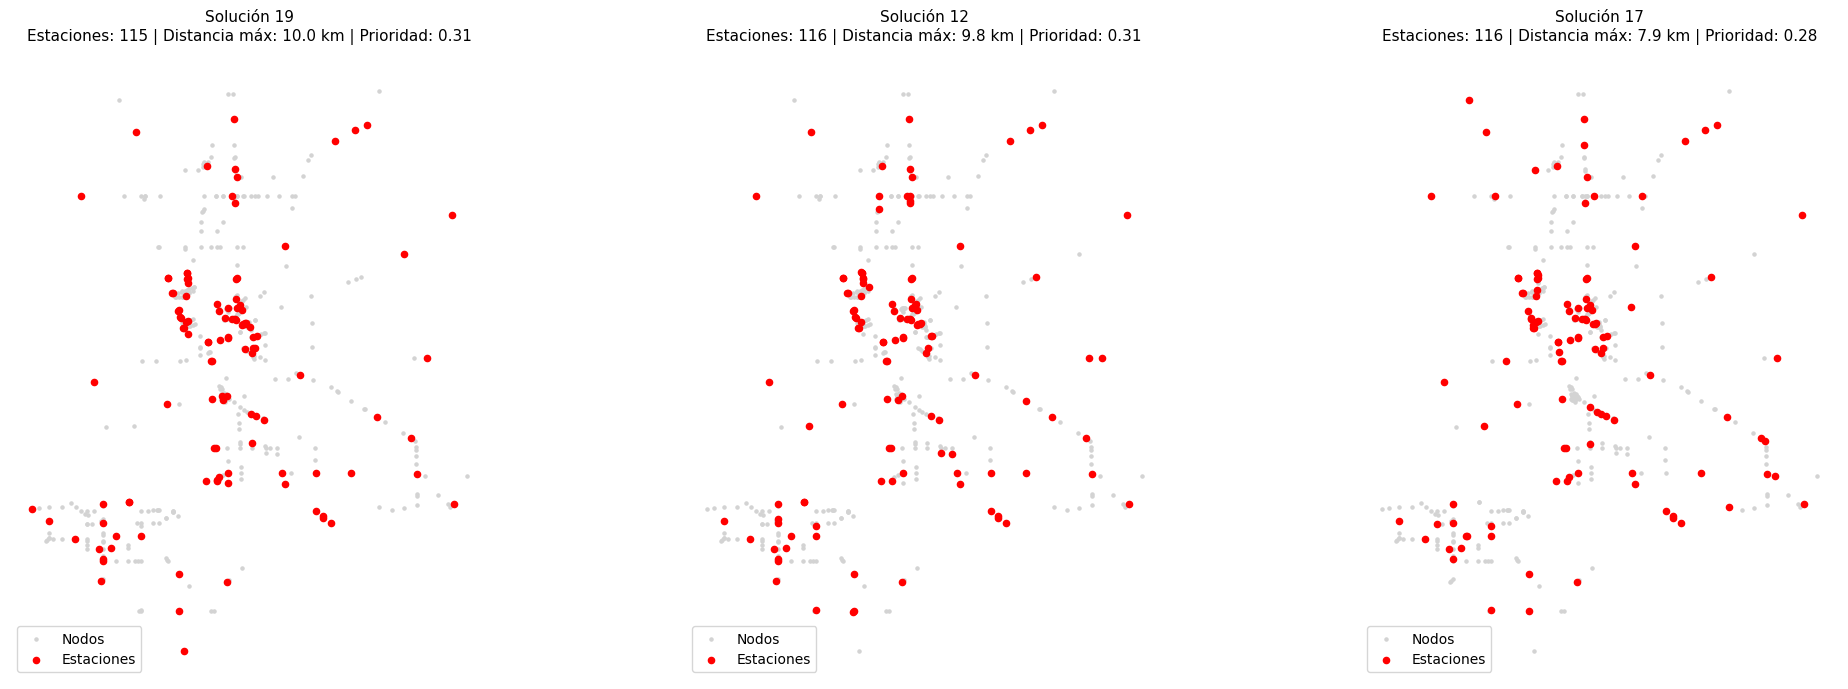

    indice  num_estaciones  distancia_max_km  prioridad_media  \
19      19             115         10.010000         0.308388   
12      12             116          9.794054         0.307125   
17      17             116          7.916810         0.277378   

                                     estaciones_osmid  
19  [90876852, 90924907, 90851854, 12662819183, 12...  
12  [90876852, 12219477898, 90924907, 90851854, 90...  
17  [8315283498, 90876964, 90876852, 90924907, 908...  
    indice  num_estaciones  distancia_max  cobertura_promedio  \
19      19             115   10010.000000         1769.588004   
10      10             116    8659.076611         1556.199861   
17      17             116    7916.809985         1484.292367   
12      12             116    9794.053901         1598.587979   
39      39             116    7916.809985         1484.292367   

    prioridad_media  %_nodos_cubiertos  eficiencia  \
19         0.308388          99.180328    0.862438   
10         0.289

In [ ]:
# ------------------ Ejecución del modelo ------------------

n_nodos = len(gdf)

# Variables modificables
d_max = 10000 # Distancia max que se tolera entre un nodo y la estacion de carga mas cercana
pop_size = 200
n_gen = 1500
factor_est = 10 # Importancia que se le de a la minimizacion de estaciones de carga (factor)


# Generar población inicial aleatoria
X_init = np.random.randint(0, 2, size=(pop_size, n_nodos))


algorithm = NSGA2(pop_size=pop_size, eliminate_duplicates=True)

res = minimize(
    EVChargingProblem3F(gdf, d_max=d_max, factor_estaciones=factor_est),
    algorithm,
    ('n_gen', n_gen),
    seed=23,
    verbose=True,
    save_history=True,
    X=X_init
)


# Imprimir resultados de optimizacion
print("Frontera de Pareto (f1: estaciones, f2: distancia, f3: calidad invertida):")
print(res.F)


# Selección de las 3 soluciones con menos estaciones (ejemplo de como seleccionar una solucion que se prefiera)
df_mejores = interpretar_y_graficar_mejores(EVChargingProblem3F(gdf, d_max=d_max, factor_estaciones=factor_est), res.X, res.F, gdf, n_mejores=3)
print(df_mejores)


# Validación de resultados
df_validacion = validar_soluciones(
    problem=EVChargingProblem3F(gdf, d_max=d_max),
    X=res.X,
    F=res.F,
    gdf=gdf
)
print(df_validacion.sort_values("eficiencia", ascending=False).head(5))

In [ ]:
F = np.array(res.F)  # Asegurarse de que esté en formato numpy array

# Crear figura 3D interactiva
fig = go.Figure(data=[go.Scatter3d(
    x=F[:, 0],  # f1
    y=F[:, 1],  # f2
    z=F[:, 2],  # f3
    mode='markers',
    marker=dict(
        size=6,
        color=F[:, 2],          # color según calidad invertida
        colorscale='Viridis',   # escala de color bonita
        opacity=0.9,
        colorbar=dict(title="Calidad invertida")
    ),
    text=[f"Estaciones: {f1:.3f}<br>Distancia: {f2:.3f}<br>Calidad Inv: {f3:.3f}"
          for f1, f2, f3 in F],
    hoverinfo='text'
)])

# Configurar layout del gráfico
fig.update_layout(
    title="🌈 Frente de Pareto 3D — Estaciones vs Distancia vs Calidad",
    scene=dict(
        xaxis_title="f1: Estaciones (normalizado)",
        yaxis_title="f2: Distancia (normalizada)",
        zaxis_title="f3: Calidad invertida",
    ),
    width=900,
    height=700,
)

fig.show()
